---
title: "CITE-seq Multi-omics Integration with Muon"
author: 
  - "Maximilian Nuber" 
  - "Junyan Lu"
format: 
  html: 
    page-layout: full
    code-fold: false        # fold all executable code blocks
    code-summary: "Show code"   # text on the disclosure widget (optional)
    code-tools: true       # optional: global "Show/Hide All Code" menu
    toc: true
    number-sections: true
    number-depth: 3
    theme: book.scss
    embed-resources: true
execute:
  echo: true               # code is present, so it can be folded
  warning: false           # still suppress warnings
  message: false           # suppress messages
---

# Surface Protein Processing

CITE-seq (Cellular Indexing of Transcriptomes and Epitopes by Sequencing) represents a landmark shift in single-cell genomics, enabling the simultaneous capture of the transcriptome and surface protein levels (Epitopes) within the same individual cell (Stoeckius et al., Nature Methods, 2017).

As outlined in the Single-cell Best Practices (Heumos et al., Nature Reviews Genetics, 2023), these two layers of information provide complementary biological perspectives. While the RNA layer captures the "transcriptional program" (the cell's underlying state and future intent), the Antibody-Derived Tag (ADT) layer provides a direct readout of the current functional phenotype through surface protein expression.
Why do we need both?

- Overcoming RNA Sparsity: mRNA transcripts are often sparse due to technical "dropout" and low capture efficiency. In contrast, surface proteins are typically present in much higher copy numbers per cell. This makes ADTs far more reliable for identifying cell types defined by classic lineage markers like CD3, CD4, CD8, and CD19.

- Bridging the Central Dogma Gap: mRNA levels do not always correlate strongly with protein levels due to post-transcriptional regulation and differing half-lives of molecules. By measuring both, we can identify cases where a cell is transcribing a gene but not yet translating the protein, or vice-versa.

- Higher-Resolution Phenotyping: In immune profiling, protein data often allows for the separation of subtle cell states (e.g., memory vs. naive T-cells or specific myeloid subsets) that appear as a single "cloud" in RNA-only space.

**The MuData Framework**

In this notebook, we utilize the MuData (Multimodal Data) structure via the muon library (Bredikhin et al., Genome Biology, 2022). Unlike standard single-modality objects, MuData allows us to keep the RNA and Protein assays in separate containers (modalities) while maintaining a global index of shared cells. This architecture is essential for performing modality-specific preprocessing (like CLR normalization for proteins) before merging them into a joint integrated analysis.

In [1]:
import matplotlib.pyplot as plt
import muon as mu
import scanpy as sc

import pandas as pd
import numpy as np

import os
import scvi

/home/rstudio/project/03_cite_seq/.venv/lib/python3.13/site-packages/muon/_core/preproc.py:31: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  if Version(scanpy.__version__) < Version("1.10"):


In [2]:
cite_seq_data_path = "/home/rstudio/project/03_cite_seq/data"
if not "pbmc_10k_protein_v3.h5ad" in os.listdir(cite_seq_data_path):
    scvi.data.pbmcs_10x_cite_seq(cite_seq_data_path)

adata = sc.read_h5ad(os.path.join(cite_seq_data_path, "pbmc_10k_protein_v3.h5ad"))
mat = adata.obsm["protein_expression"]

df = pd.DataFrame(mat, columns=adata.uns["protein_names"], index=adata.obs_names)

prot = sc.AnnData(df)

del mat, df, adata.obsm["protein_expression"], adata.uns["protein_names"]

mdata = mu.MuData({"rna": adata, "prot": prot})

/home/rstudio/project/03_cite_seq/.venv/lib/python3.13/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/rstudio/project/03_cite_seq/.venv/lib/python3.13/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


## The MuData Structure

Why are we doing this?

- MuData keeps each modality in its own slot, so RNA and protein can have their own features, quality-control metrics, normalization steps, and embeddings.
- Both modalities still point to the same cells, which is why `mdata.mod["rna"]` and `mdata.mod["prot"]` can be compared directly.
- This is the key advantage of a multi-omic object: we get separation where the measurements differ and alignment where the biology is shared.

The Bottom Line: A MuData object is one coordinated container with two analytical views of the same cells, which makes multi-omic comparison much cleaner than juggling separate objects.

In [3]:
rna = mdata.mod["rna"]
prot = mdata.mod["prot"]

print(mdata)
print("Modalities:", list(mdata.mod.keys()))
print("RNA shape:", rna.shape)
print("Protein shape:", prot.shape)
print("Shared barcodes:", rna.obs_names.equals(prot.obs_names))
print("First five barcodes:", rna.obs_names[:5].tolist())

MuData object with n_obs × n_vars = 6855 × 16741
  2 modalities
    rna:	6855 × 16727
      obs:	'n_genes', 'percent_mito', 'n_counts'
      var:	'n_cells', 'highly_variable', 'encode', 'hvg_encode'
    prot:	6855 × 14
Modalities: ['rna', 'prot']
RNA shape: (6855, 16727)
Protein shape: (6855, 14)
Shared barcodes: True
First five barcodes: ['AAACCCAAGATTGTGA-1', 'AAACCCACATCGGTTA-1', 'AAACCCAGTACCGCGT-1', 'AAACCCAGTATCGAAA-1', 'AAACCCAGTCGTCATA-1']


## Data Loading

Why are we doing this?

- The PBMC 5k CITE-seq dataset gives us paired RNA and ADT measurements from the same cells, which is exactly the kind of data MuData was designed to organize.
- Loading the data as a single object keeps the modalities synchronized from the start.
- That makes it easier to compare transcriptional state and protein phenotype without manually matching cells later.

The Bottom Line: `mu.datasets.pbmc5k_citeseq()` brings the full multi-omic dataset into one MuData container, ready for RNA and protein analysis together.

## Modality-Specific QC

Why are we doing this?

- RNA quality control is usually based on familiar filters like detected gene counts and the fraction of mitochondrial reads.
- Protein quality control is different: the main issue is the ambient protein problem, where antibody-derived tags can pick up background noise from free-floating antibody aggregates or nonspecific capture.
- Keeping RNA and protein QC separate avoids metadata collisions and makes it clear which layer each threshold belongs to.

The Bottom Line: We filter the RNA layer with standard QC rules, but we treat the protein layer as its own measurement with its own background-noise issues.

In [4]:
rna = mdata.mod["rna"]
prot = mdata.mod["prot"]

rna.var["mt"] = rna.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(rna, qc_vars=["mt"], percent_top=None, inplace=True, log1p=False)
sc.pp.calculate_qc_metrics(prot, percent_top=None, inplace=True, log1p=False)

rna_mask = (rna.obs["n_genes_by_counts"] >= 200) & (rna.obs["pct_counts_mt"] < 20)
mdata = mdata[rna_mask].copy()
rna = mdata.mod["rna"]
prot = mdata.mod["prot"]

/home/rstudio/project/03_cite_seq/.venv/lib/python3.13/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/rstudio/project/03_cite_seq/.venv/lib/python3.13/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


## Normalization

Why are we doing this?

- RNA counts are still affected by sequencing depth, so we log-transform them after saving the raw counts.
- ADT counts are compositional and have a very wide dynamic range, so CLR normalization is usually a better fit than RNA-style library-size scaling.
- CLR also helps reduce the impact of highly abundant or aggregated antibody signal.

The Bottom Line: RNA and protein need different normalization rules because they behave differently, and the protein layer is especially vulnerable to background capture and ambient protein contamination.

In [5]:
rna.layers["counts"] = rna.X.copy()
prot.layers["counts"] = prot.X.copy()

## some technical thing, we need to convert the counts to float before log1p, otherwise we get an error about overflow
prot.X = prot.X.astype(float)

sc.pp.log1p(rna)
mu.prot.pp.clr(prot)

## Feature Selection and Dimensionality Reduction

Why are we doing this?

- RNA is still high-dimensional after normalization, so we keep the genes that actually vary across cells and summarize them with PCA.
- Protein panels are much smaller, so we can run PCA directly on the CLR-transformed ADT matrix without a separate highly variable gene step.
- Building neighbors and UMAPs separately keeps each modality honest: each embedding reflects the structure that modality sees best.

The Bottom Line: RNA gives us transcript-level patterns, protein gives us surface-phenotype patterns, and PCA plus UMAP turn both into readable cell maps.

In [6]:
sc.pp.highly_variable_genes(rna, n_top_genes=2000, flavor="seurat")
sc.pp.pca(rna, n_comps=30, use_highly_variable=True)

sc.pp.pca(prot, n_comps=10)

sc.pp.neighbors(rna, n_neighbors=15, n_pcs=30)
sc.tl.umap(rna)

sc.pp.neighbors(prot, n_neighbors=15, n_pcs=10)
sc.tl.umap(prot)

/tmp/ipykernel_511022/1591612344.py:2: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  sc.pp.pca(rna, n_comps=30, use_highly_variable=True)


## Joint Visualization

Why are we doing this?

- RNA and protein are different measurements of the same cells, so the most useful comparison is to put them side-by-side.
- Surface proteins often separate immune populations more cleanly than RNA because markers such as CD3, CD4, and CD19 are measured directly instead of inferred from sparse transcripts.
- Using the same barcode set lets us compare the same biological cells across both views.

The Bottom Line: If the RNA and protein embeddings tell a similar story, that is a good sign that we are measuring real biology rather than modality-specific noise.

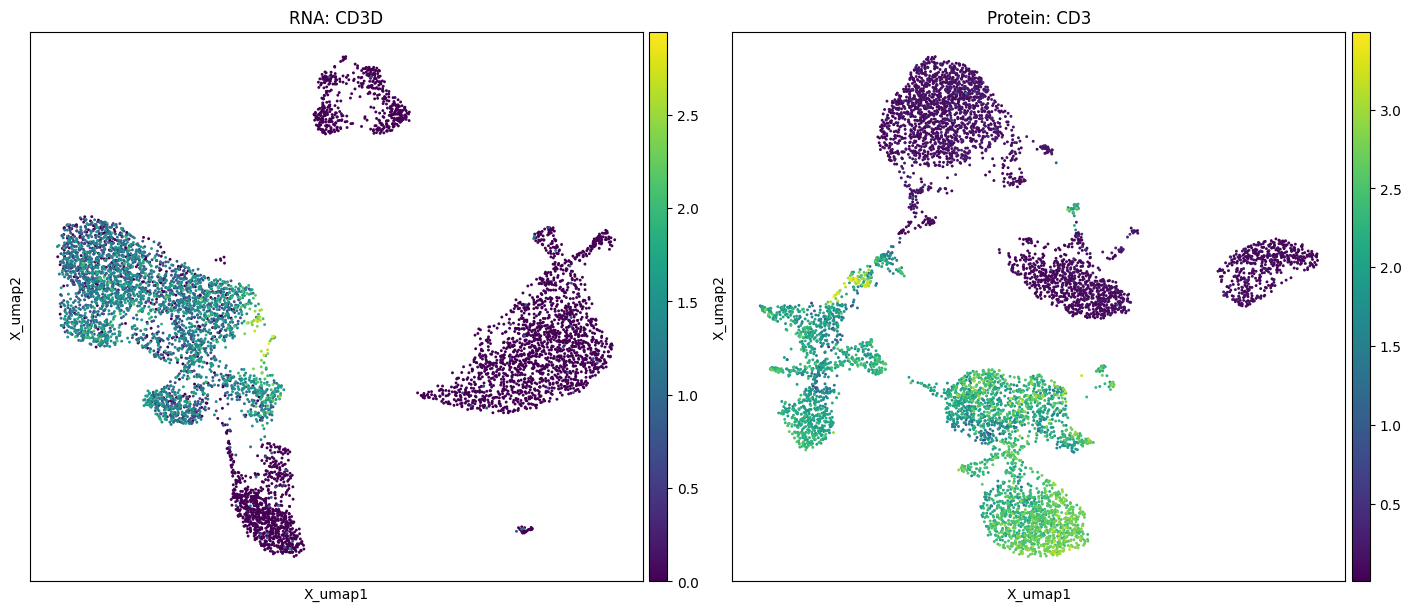

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

mu.pl.embedding(
    mdata,
    basis="rna:X_umap",
    color="CD3D",
    ax=axes[0],
    show=False,
)
axes[0].set_title("RNA: CD3D")

mu.pl.embedding(
    mdata,
    basis="prot:X_umap",
    color="CD3_TotalSeqB",
    ax=axes[1],
    show=False,
)
axes[1].set_title("Protein: CD3")

plt.show()

Some references:

Original Method: Stoeckius, M., et al. (2017). "Simultaneous epitope and transcriptome measurement in single cells." Nature Methods.

Analysis Standards: Heumos, S., et al. (2023). "Best practices for single-cell analysis across modalities." Nature Reviews Genetics.

MuData Framework: Bredikhin, D., et al. (2022). "muon: multimodal omics analysis framework." Genome Biology.

Normalization Logic: Aitchison, J. (1982). "The Statistical Analysis of Compositional Data" (The basis for CLR normalization used in ADT processing).

# Joint Multi-omics Integration: Weighted Nearest Neighbors (WNN)

Up to this point, we have treated RNA and Protein as two separate datasets. But the goal of multi-omics is to combine them into a single "consensus" view of the cell.

A simple approach would be to just concatenate the two matrices. However, RNA typically has 20,000+ features, while our CITE-seq protein panel might only have 30. If we just merge them, the RNA signal will completely drown out the protein signal.

Weighted Nearest Neighbors (WNN), introduced by Hao et al. (Cell, 2021), solves this by calculating "modality weights" for every cell. If a cell has a very clear protein signal (like a T-cell with high CD3) but a noisy or sparse RNA profile, the algorithm will "trust" the protein more for that specific cell when deciding who its neighbors are.

## Preprocessing for WNN

Before we can calculate joint neighbors, both modalities must have their own dimensionality reduction (PCA) completed.

In [8]:
# 1. Preprocess RNA
sc.pp.highly_variable_genes(mdata.mod['rna'], n_top_genes=2000)
sc.tl.pca(mdata.mod['rna'])

# 2. Preprocess Protein
# Proteins don't need "Highly Variable Gene" selection as the panel is already curated.
# We run PCA on the CLR-normalized protein counts.
sc.tl.pca(mdata.mod['prot'])

Why are we doing this?

- WNN doesn't look at the raw counts; it looks at the individual neighbor graphs per modality. First,  need to summarize the thousands of RNA genes into 50 PCs and the 30 proteins into roughly 15-20 PCs so the algorithm can compare them on a similar mathematical scale, and from the PCs then calculate a cell-cell graph (in the next step)

## Calculating the WNN Graph

Now we use muon to find the joint neighbors. This is where the integration "magic" happens.

In [9]:
# Calculate joint neighbors using both modalities
sc.pp.neighbors(mdata['rna'])
sc.pp.neighbors(mdata['prot'])

# Calculate weighted nearest neighbors
mu.pp.neighbors(mdata, key_added='wnn')


# Calculate a joint UMAP based on this integrated graph
mu.tl.umap(mdata, neighbors_key='wnn', random_state=10)

/home/rstudio/project/03_cite_seq/.venv/lib/python3.13/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


Why are we doing this?

- `mu.pp.neighbors`: For every cell, the computer looks at its RNA neighbors and its Protein neighbors. It then calculates how much "predictive power" the RNA has over the Protein (and vice-versa).

- If the RNA and Protein agree on who the neighbors are, the cell gets a balanced weight. If the Protein provides a much clearer separation (common in immune cells), the Protein weight increases.

The Bottom Line: We are building a "social network" of cells where the connections are weighted by the quality of information in each modality.

## Visualizing the Integrated Landscape

Finally, we can look at the UMAP generated from the joint graph and inspect the "Modality Weights."

/home/rstudio/project/03_cite_seq/.venv/lib/python3.13/site-packages/mudata/_core/mudata.py:1416: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/home/rstudio/project/03_cite_seq/.venv/lib/python3.13/site-packages/mudata/_core/mudata.py:1272: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


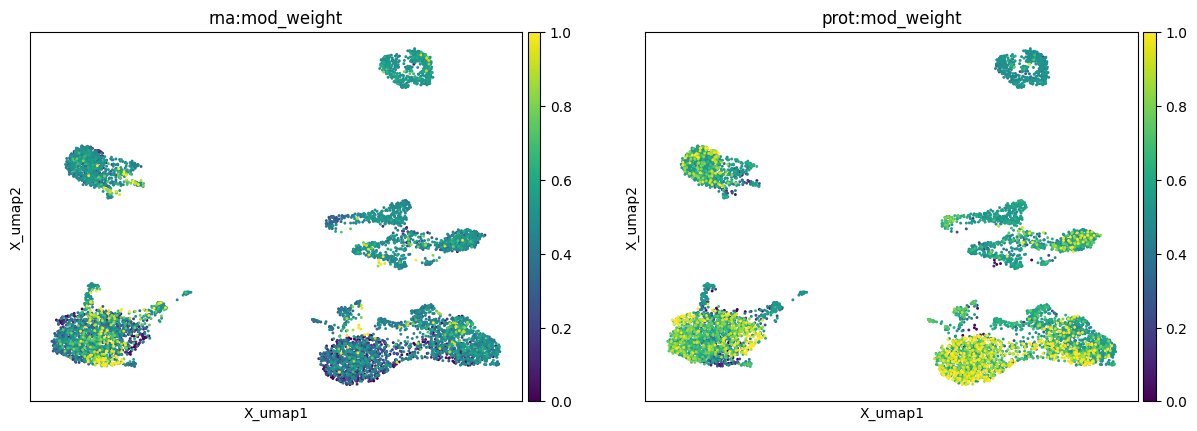

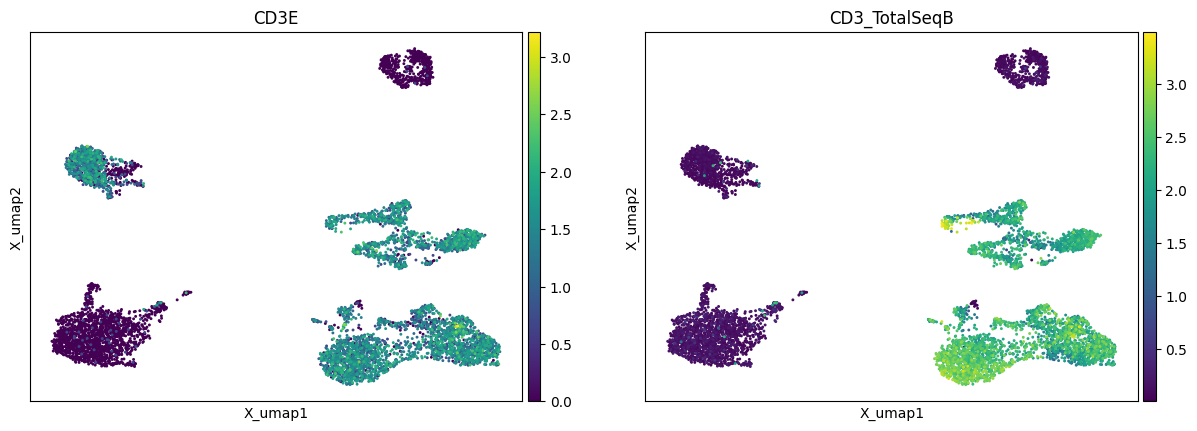

In [10]:
mdata.update()
# Plot the joint UMAP
mu.pl.embedding(mdata, basis="umap", color=["rna:mod_weight", "prot:mod_weight"], cmap="viridis")

# Compare with a known marker
mu.pl.embedding(mdata, basis="umap", color=["rna:CD3E", "prot:CD3_TotalSeqB"])

Why are we doing this?

- `rna_weight` vs. `prot_weight`: This shows you which cells "preferred" which modality. You will often see that T-cells and B-cells rely heavily on the Protein modality (high prot_weight) because the surface antibodies provide such a clean signal compared to sparse mRNA.

- Side-by-side comparison: By plotting the RNA version of a gene (CD3E) next to its Protein version (CD3), you can see how much "cleaner" the protein blobs usually are.

The Bottom Line: The WNN UMAP represents the "best of both worlds." It preserves the fine-grained state information from the RNA while using the high-protein signal to sharpen the boundaries between cell types.

# The Interpretable Bridge: MOFA+ for Single Cells
In your previous R-based bulk MOFA experience, you likely used Factors to explain differences between samples—identifying, for example, why a "Healthy" patient group differs from a "Treated" group. In single-cell multi-omics, the observations shift from a handful of samples to thousands of individual cells. Because of the extreme sparsity (dropout) and "noise" inherent to single cells, we cannot interpret a single factor as a clean experimental "variable" like we do in bulk. Instead, we use MOFA+ to find coordinated biological programs—such as cell cycle stages, metabolic shifts, or differentiation gradients—that manifest across both the transcriptome and the proteome simultaneously.

Why we use it in Single-Cell:
- Variance Decomposition: Unlike WNN, which gives you a graph, MOFA+ tells you exactly how much "information" is shared between RNA and Protein, and how much is unique to just one modality.

- Dimensionality Reduction for Clustering: The latent factors serve as an integrated embedding. We use these factors as the input for clustering because they have already filtered out the modality-specific noise that might lead to "batch-like" separation.

- Feature Weighting (Loadings): It allows us to look "under the hood" of our clusters. If a cluster is defined by Factor 3, we can inspect the top RNA and Protein weights to see which specific genes and surface markers are driving that cellular identity.

The Bottom Line: In bulk, MOFA is a destination (the factors are the results). In single-cell, MOFA+ is a foundation—it provides the clean, integrated coordinates we need to perform reliable clustering and downstream pseudobulk analysis.

In [11]:
if not os.path.exists("results/cite_seq_integrated.h5mu"):
    if not os.path.exists("results"):
        os.mkdir("results")
    mdata.write_h5mu("results/cite_seq_integrated.h5mu")

In [12]:
mu.tl.mofa(mdata, outfile="models/pbmc5k_citeseq.hdf5",
           n_factors=30)



        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
         




Loaded view='rna' group='group1' with N=6855 samples and D=16727 features...
Loaded view='prot' group='group1' with N=6855 samples and D=14 features...




Model options:
- Automatic Relevance Determination prior on the factors: True
- Automatic Relevance Determination prior on the weights: True
- Spike-and-slab prior on the factors: False
- Spike-and-slab prior on the weights: True
Likelihoods:
- View 0 (rna): gaussian
- View 1 (prot): gaussian








######################################
## Training the model with seed 1 ##
######################################





Converged!



#######################
## Training finished ##
#######################


Saving model in models/pbmc5k_citeseq.hdf5...


Saved MOFA embeddings in .obsm['X_mofa'] slot and their loadings in .varm['LFs'].


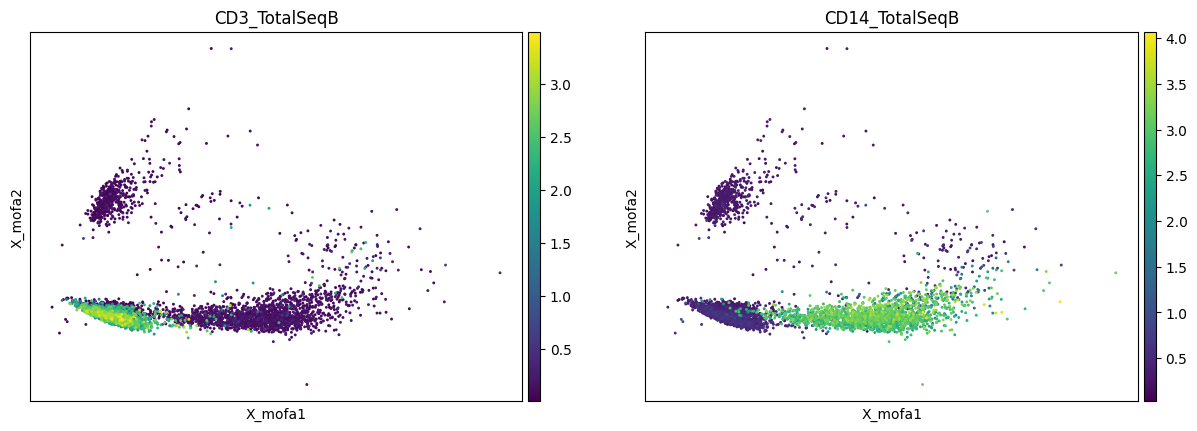

In [13]:
mu.pl.mofa(mdata, color=['CD3_TotalSeqB', 'CD14_TotalSeqB'])

In [14]:
sc.pp.neighbors(mdata, use_rep="X_mofa")
sc.tl.umap(mdata, random_state=1)
sc.tl.leiden(mdata, resolution=0.5, key_added="leiden_mofa", flavor="igraph")

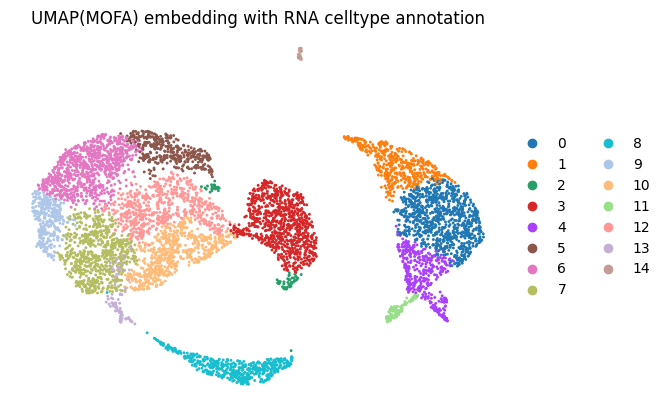

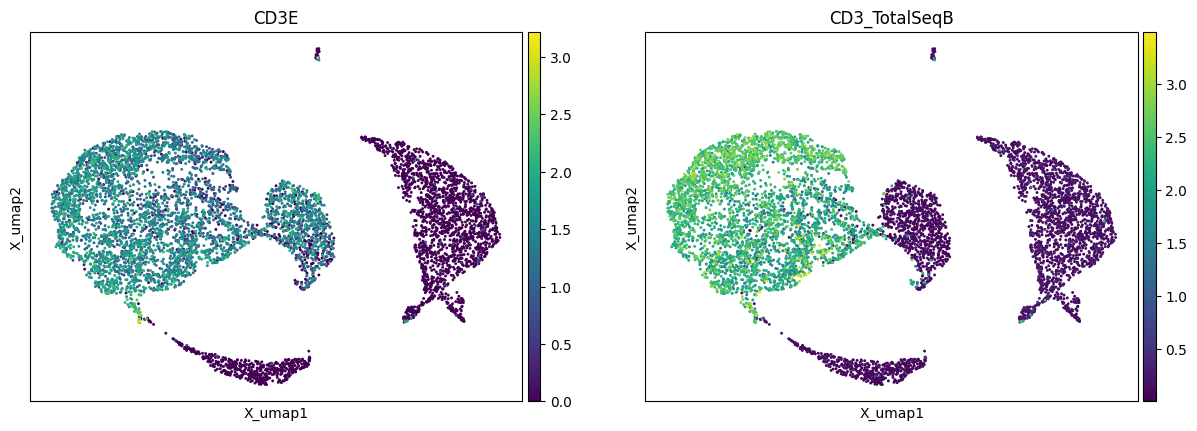

In [15]:
import matplotlib

mu.pl.umap(mdata, color=['leiden_mofa'], frameon=False,
           title="UMAP(MOFA) embedding with RNA celltype annotation")

mu.pl.embedding(mdata, basis="umap", color=["rna:CD3E", "prot:CD3_TotalSeqB"])